<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>n_bolus_duplicates</th>
      <th>n_basal_duplicates</th>
      <th>n_cgm_duplicates</th>
      <th>n_basal_repetitive</th>
      <th>n_basal_events</th>
      <th>n_bolus_events</th>
      <th>n_cgm_events</th>
      <th>n_patients</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>IOBP2</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>2304446</td>
      <td>8640808</td>
      <td>1730983</td>
      <td>7891499</td>
      <td>343</td>
    </tr>
    <tr>
      <th>Flair</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>44945</td>
      <td>142653</td>
      <td>3388050</td>
      <td>5506402</td>
      <td>115</td>
    </tr>
    <tr>
      <th>PEDAP</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>2654543</td>
      <td>263076</td>
      <td>6622228</td>
      <td>99</td>
    </tr>
    <tr>
      <th>DCLP3</th>
      <td>39</td>
      <td>2</td>
      <td>49</td>
      <td>2603</td>
      <td>2594186</td>
      <td>207682</td>
      <td>5673877</td>
      <td>112</td>
    </tr>
    <tr>
      <th>DCLP5</th>
      <td>33</td>
      <td>0</td>
      <td>5</td>
      <td>90318</td>
      <td>2529818</td>
      <td>226685</td>
      <td>5535106</td>
      <td>100</td>
    </tr>
    <tr>
      <th>ReplaceBG</th>
      <td>0</td>
      <td>0</td>
      <td>436</td>
      <td>64986</td>
      <td>448395</td>
      <td>414508</td>
      <td>13722600</td>
      <td>208</td>
    </tr>
    <tr>
      <th>Loop</th>
      <td>54</td>
      <td>0</td>
      <td>2227265</td>
      <td>10502324</td>
      <td>48080493</td>
      <td>2424001</td>
      <td>91431098</td>
      <td>845</td>
    </tr>
    <tr>
      <th>T1DEXI</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>244751</td>
      <td>1052843</td>
      <td>85440</td>
      <td>3756150</td>
      <td>489</td>
    </tr>
    <tr>
      <th>T1DEXIP</th>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>29236</td>
      <td>219453</td>
      <td>19122</td>
      <td>679913</td>
      <td>239</td>
    </tr>
  </tbody>
</table>
</div>

We know that we have a lot of repetitive basal rates that should be removed to reduce computational burden.
For PEDAP we already did this, however, this might create long gaps when basal rates are constant for a long time (flat basal).
Then, it is unclear if basal data was missing or we removed it. So dropping repetitive values should not create too large gaps.

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
def integrate_zoh(df):
    x = (df.datetime.diff().dt.total_seconds()/3600)[1:]
    y = df['basal_rate'][:-1]
    if len(x) == 0:
        r= np.nan
    else:
        r = np.sum(x.values * y.values)
    return r

def draw_basal(df,ax):
    df = df.sort_values('datetime')
    ax.step(df['datetime'], df['basal_rate'], where='post', color='blue', alpha=0.5)
    ax.scatter(df['datetime'], df['basal_rate'], s=5, color='blue')
    return ax


## Generate artificial dataset

,datetime,basal_rate
0,2023-01-03 02:00:00,1.0
1,2023-01-03 08:00:00,0.5
2,2023-01-03 19:00:00,0.5
3,2023-01-02 15:00:00,0.5


-137.0

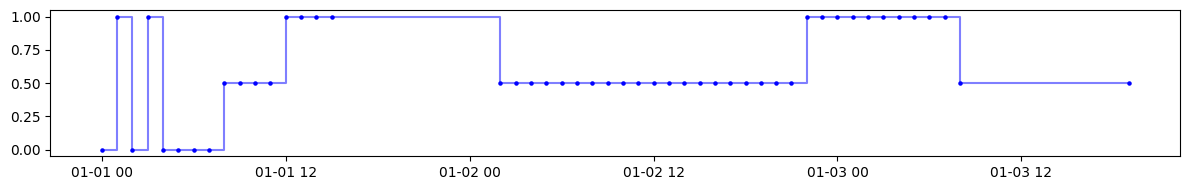

In [3]:
# Generate a date range with 1-hour intervals
start_date = '2023-01-01'
values = (
    [0,1,0,1] * 1 + 
    [0] * 4 + 
    [0.5] * 4 + 
    [1] * 4 + 
    [np.nan] * 10 + 
    [0.5] * 20 + 
    [1]*10+
    [0.5]*1+
    [np.nan] * 10 +
    [0.5]*1
)
date_range = pd.date_range(start=start_date, periods=len(values), freq='1h')

df = pd.DataFrame({
    'datetime': date_range,
    'basal_rate': values
}).dropna()
df = df.sample(frac=1).reset_index(drop=True)
display(df.head(4))

f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.tight_layout()

integral = integrate_zoh(df)
display(integral)


## dropping repetitive values

In [4]:
#first, find repetitive values
def get_repetitive_groups(df,datetime_col,value_col):
#    assert df[datetime_col].is_monotonic_increasing
    df = df.sort_values(datetime_col)
    grp = (df[value_col].diff() != 0).cumsum()
    return grp

,original,filtered,difference
0,-137.0,38.0,175.0


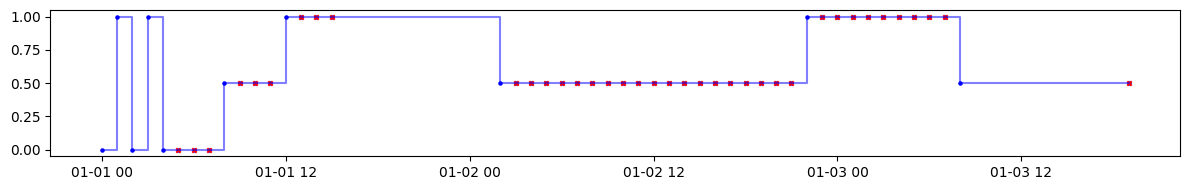

In [5]:
#get the repetitive rows
df = df.sort_values('datetime') 
df['grp'] = get_repetitive_groups(df,'datetime','basal_rate')
df_filtered = df.groupby('grp').head(1) #head(1) returns the first row, therefore must be sorted
df_repetitive = df.drop(df_filtered.index)

#draw and mark the repetitive values in red
f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.scatter(df_repetitive['datetime'], df_repetitive['basal_rate'], s=10, color='red',marker='x')
plt.tight_layout()

integral_filtered = integrate_zoh(df_filtered)
# Merge the integrals into a DataFrame and calculate the difference
integrals = pd.DataFrame({'original': [integral], 'filtered': [integral_filtered]})
integrals['difference'] = integrals['filtered'] - integrals['original']

# Display the integrals and the difference
display(integrals)

## Keep last values
Since we remvoe the last value, the integral is not calculated correctly, so we need to always keep the last value.

,original,filtered,difference
0,-137.0,43.5,180.5


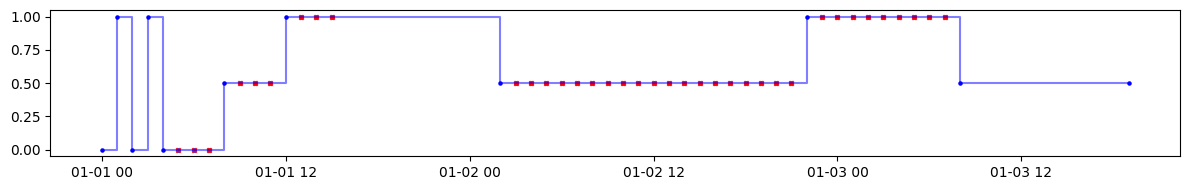

In [6]:
df.loc[df.tail(1).index,'grp']+=1

i_grp_starts = df.groupby(['grp']).head(1).index
df_filtered = df.loc[i_grp_starts]
df_repetitive = df.drop(i_grp_starts)

#draw and mark the repetitive values in red
f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.scatter(df_repetitive['datetime'], df_repetitive['basal_rate'], s=10, color='red',marker='x')
plt.tight_layout()

integral_filtered = integrate_zoh(df_filtered)
# Merge the integrals into a DataFrame and calculate the difference
integrals = pd.DataFrame({'original': [integral], 'filtered': [integral_filtered]})
integrals['difference'] = integrals['filtered'] - integrals['original']

# Display the integrals and the difference
display(integrals)


## Maintain support points
The problem is now, that we remove all repetitions, in the middle this could be incorrectly intterpreted as missing data. Therefore we want to add support points at least every x hours.

,original,filtered,difference
0,-137.0,43.5,180.5


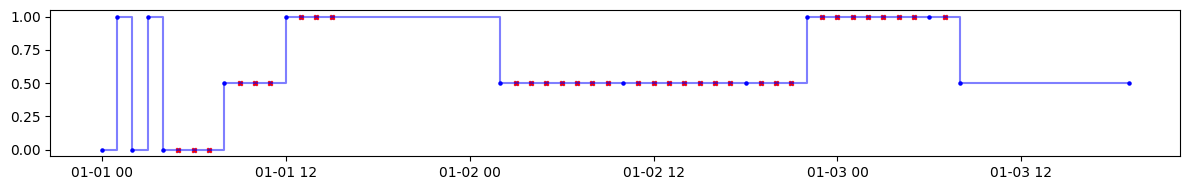

In [7]:
max_duration = pd.Timedelta(hours=8)
df['sub_grped'] = df.groupby(['grp']).datetime.transform(lambda x: (x.diff()).cumsum()//max_duration).fillna(0)
df['sub_grped'] = df['grp']*10000 + df['sub_grped']

df_filtered = df.groupby(['sub_grped']).head(1)
df_repetitive = df.drop(df_filtered.index)

#draw and mark the repetitive values in red
f = plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
plt.scatter(df_repetitive['datetime'], df_repetitive['basal_rate'], s=10, color='red',marker='x')
plt.tight_layout()

integral_filtered = integrate_zoh(df_filtered)
# Merge the integrals into a DataFrame and calculate the difference
integrals = pd.DataFrame({'original': [integral], 'filtered': [integral_filtered]})
integrals['difference'] = integrals['filtered'] - integrals['original']

# Display the integrals and the difference
display(integrals)



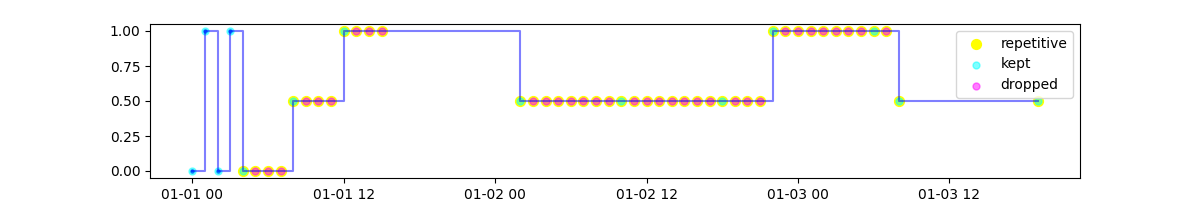

In [8]:
import line_profiler as lp

%matplotlib widget
def get_repetitive_indexes(df, datetime_col, value_col, max_duration):
    df = df.sort_values(datetime_col) 
    grp = get_repetitive_groups(df,datetime_col,value_col)
    i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
    
    #keep last value
    grp.iloc[-1] += 1 
    
    #subsplit groups
    sub_grp = grp*10000 + df.groupby(grp).datetime.transform(lambda x: (x.diff()).cumsum()//max_duration).fillna(0)
    
    #keep only the first of each subgroup
    i_keep = sub_grp[sub_grp.duplicated(keep='first') == False].index
    i_drop = np.setdiff1d(i_all_repetitives, i_keep)
    return i_all_repetitives, i_keep, i_drop

i_all_repetitives, i_keep, i_drop = get_repetitive_indexes(df, 'datetime', 'basal_rate', max_duration=max_duration)
    

plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
temp = df.loc[i_all_repetitives]

plt.scatter(temp['datetime'], temp['basal_rate'], s=50, color='yellow',marker='o',alpha=1,label='repetitive')
temp = df.loc[i_keep]
plt.scatter(temp['datetime'], temp['basal_rate'], s=25, color='cyan',marker='o',alpha=.5,label='kept')
temp = df.loc[i_drop]
plt.scatter(temp['datetime'], temp['basal_rate'], s=25, color='magenta',marker='o',alpha=.5,label='dropped')
plt.legend()


## Benchmark speed

In [34]:
n_samples = 100000
max_duration = pd.Timedelta(hours=2)
basal_rate = np.random.choice([0,1,1,1,1,1], size=n_samples)
datetime = pd.date_range(start='2023-01-01', periods=n_samples, freq='1h')
df = pd.DataFrame({'datetime': datetime, 'basal_rate': basal_rate})


In [35]:
import line_profiler
lp = line_profiler.LineProfiler()
lp.add_function(get_repetitive_indexes)
get_repetitive_indexes_wrapper = lp.wrap_function(get_repetitive_indexes)

i_all_repetitives, i_keep, i_drop = get_repetitive_indexes_wrapper(df, 'datetime', 'basal_rate', max_duration=max_duration)

lp.print_stats()
stats = lp.get_stats()
for key in stats.timings.keys():
    print(key[0])
    print(f'Execution time {sum([t[2] for t in stats.timings[key]])/1000000000:.6f} seconds')


Timer unit: 1e-09 s

Total time: 5.49827 s
File: /var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_9228/1034689870.py
Function: get_repetitive_indexes at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           def get_repetitive_indexes(df, datetime_col, value_col, max_duration):
     5         1    2658000.0    3e+06      0.0      df = df.sort_values(datetime_col) 
     6         1    2356000.0    2e+06      0.0      grp = get_repetitive_groups(df,datetime_col,value_col)
     7         1    3865000.0    4e+06      0.1      i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
     8                                               
     9                                               #keep last value
    10         1     132000.0 132000.0      0.0      grp.iloc[-1] += 1 
    11                                               
    12                                               #subsplit groups
    13        

## implement a improved version

,datetime,basal_rate
2,2023-01-01 02:00:00,1
3,2023-01-01 03:00:00,1
6,2023-01-01 06:00:00,1
7,2023-01-01 07:00:00,1
8,2023-01-01 08:00:00,1
9,2023-01-01 09:00:00,1
11,2023-01-01 11:00:00,1
13,2023-01-01 13:00:00,1
16,2023-01-01 16:00:00,1
17,2023-01-01 17:00:00,1


Timer unit: 1e-09 s

Total time: 0.015711 s
File: /var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_9228/1562665740.py
Function: get_repetitive_indexes_improved at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def get_repetitive_indexes_improved(df, datetime_col, value_col, max_duration):
     2         1    1689000.0    2e+06     10.8      df = df.sort_values(datetime_col) 
     3         1    1970000.0    2e+06     12.5      grp = get_repetitive_groups(df,datetime_col,value_col)
     4         1    2863000.0    3e+06     18.2      i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
     5                                               
     6                                               #keep last value
     7         1      95000.0  95000.0      0.6      grp.iloc[-1] += 1 
     8                                               
     9                                               #subsplit gr

(19358.0, 19359.0)

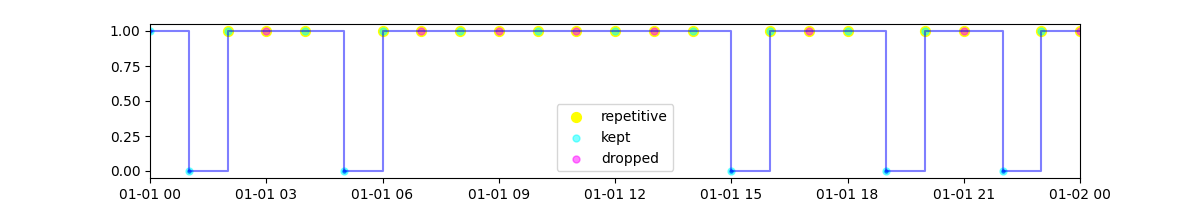

In [48]:
def get_repetitive_indexes_improved(df, datetime_col, value_col, max_duration):
    df = df.sort_values(datetime_col) 
    grp = get_repetitive_groups(df,datetime_col,value_col)
    i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
    
    #keep last value
    grp.iloc[-1] += 1 
    
    #subsplit groups
    #df['grp'] = grp
    dur = (df.datetime-df.datetime.iloc[0])
    dur = dur - dur.groupby(grp).transform('first')#within group duration
    sub_grp = dur//max_duration

    final_grp = grp*10000 + sub_grp
    df['grp'] = grp
    df['dur'] = dur
    df['sub_grp'] = sub_grp
    
    
    #keep only the first of each subgroup
    i_keep = final_grp[final_grp.duplicated(keep='first') == False].index
    i_drop = np.setdiff1d(i_all_repetitives, i_keep)
    return i_all_repetitives, i_keep, i_drop

    #return df.drop(i_drop)

import line_profiler
lp = line_profiler.LineProfiler()
lp.add_function(get_repetitive_indexes_improved)
get_repetitive_indexes_wrapper = lp.wrap_function(get_repetitive_indexes_improved)

i_all_repetitives, i_keep, i_drop = get_repetitive_indexes_wrapper(df, 'datetime', 'basal_rate', max_duration=max_duration)
display(temp.head(15))

lp.print_stats()
stats = lp.get_stats()
for key in stats.timings.keys():
    print(key[0])
    print(f'Execution time {sum([t[2] for t in stats.timings[key]])/1000000000:.6f} seconds')


plt.figure(figsize=(12, 2)); ax=plt.gca()
draw_basal(df,ax)
temp = df.loc[i_all_repetitives]
plt.scatter(temp['datetime'], temp['basal_rate'], s=50, color='yellow',marker='o',alpha=1,label='repetitive')

temp = df.loc[i_keep]
plt.scatter(temp['datetime'], temp['basal_rate'], s=25, color='cyan',marker='o',alpha=.5,label='kept')
temp = df.loc[i_drop]
plt.scatter(temp['datetime'], temp['basal_rate'], s=25, color='magenta',marker='o',alpha=.5,label='dropped')
plt.legend()

plt.xlim(df['datetime'].min(), df['datetime'].min() + pd.Timedelta(hours=24))


,datetime,basal_rate,grp,dur,sub_grp
0,2023-01-01 00:00:00,1,1,0 days 00:00:00,0
1,2023-01-01 01:00:00,0,2,0 days 00:00:00,0
2,2023-01-01 02:00:00,1,3,0 days 00:00:00,0
3,2023-01-01 03:00:00,1,3,0 days 01:00:00,0
4,2023-01-01 04:00:00,1,3,0 days 02:00:00,1
5,2023-01-01 05:00:00,0,4,0 days 00:00:00,0
6,2023-01-01 06:00:00,1,5,0 days 00:00:00,0
7,2023-01-01 07:00:00,1,5,0 days 01:00:00,0
8,2023-01-01 08:00:00,1,5,0 days 02:00:00,1
9,2023-01-01 09:00:00,1,5,0 days 03:00:00,1


In [293]:
start_time = time.time()
grp = get_repetitive_groups(df, 'datetime', 'basal_rate')
end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

start_time = time.time()
grp_gt1 = grp[grp.map(grp.value_counts()) > 1]
end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

start_time = time.time()
sub_grps = df.datetime.loc[grp_gt1.index].groupby(grp_gt1).transform(lambda x: (x.diff()).cumsum()//max_duration).dropna()
final_grps = (grp*100).add(sub_grps, fill_value=0)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")

start_time = time.time()
sub_grps = df.datetime.loc[grp_gt1.index].groupby(grp_gt1).transform(lambda x: (x.diff()).cumsum()//max_duration).dropna()
df_filtered_new = df.groupby(grp_gt1).head(1)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.6f} seconds")


df['grp'] = grp
df['sub_grp'] = sub_grps
df['final_grp'] = final_grps
display(df.head(10))
display(df.tail(10))

Execution time: 0.002755 seconds
Execution time: 0.003149 seconds
Execution time: 1.334169 seconds
Execution time: 1.315278 seconds


,datetime,basal_rate,grp,sub_grp,final_grp
0,2023-01-01 00:00:00,1,1,NaN,100.0
1,2023-01-01 01:00:00,1,1,0.0,100.0
2,2023-01-01 02:00:00,1,1,0.0,100.0
3,2023-01-01 03:00:00,0,2,NaN,200.0
4,2023-01-01 04:00:00,1,3,NaN,300.0
5,2023-01-01 05:00:00,1,3,0.0,300.0
6,2023-01-01 06:00:00,0,4,NaN,400.0
7,2023-01-01 07:00:00,0,4,0.0,400.0
8,2023-01-01 08:00:00,1,5,NaN,500.0
9,2023-01-01 09:00:00,0,6,NaN,600.0


,datetime,basal_rate,grp,sub_grp,final_grp
99990,2034-05-29 06:00:00,1,24477,3.0,2447703.0
99991,2034-05-29 07:00:00,1,24477,4.0,2447704.0
99992,2034-05-29 08:00:00,1,24477,4.0,2447704.0
99993,2034-05-29 09:00:00,1,24477,4.0,2447704.0
99994,2034-05-29 10:00:00,0,24478,NaN,2447800.0
99995,2034-05-29 11:00:00,1,24479,NaN,2447900.0
99996,2034-05-29 12:00:00,1,24479,0.0,2447900.0
99997,2034-05-29 13:00:00,1,24479,0.0,2447900.0
99998,2034-05-29 14:00:00,1,24479,1.0,2447901.0
99999,2034-05-29 15:00:00,1,24479,1.0,2447901.0


In [278]:
display(df.head(10))
display(grp.head(10))
display(sub_grps.head(10))
display(final_grps.head(10))

,datetime,basal_rate
0,2023-01-01 00:00:00,1
1,2023-01-01 01:00:00,1
2,2023-01-01 02:00:00,1
3,2023-01-01 03:00:00,1
4,2023-01-01 04:00:00,1
5,2023-01-01 05:00:00,1
6,2023-01-01 06:00:00,1
7,2023-01-01 07:00:00,1
8,2023-01-01 08:00:00,1
9,2023-01-01 09:00:00,0


0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    2
Name: basal_rate, dtype: int64

1     0.0
2     0.0
3     1.0
4     1.0
5     1.0
6     2.0
7     2.0
8     2.0
11    0.0
12    0.0
Name: datetime, dtype: float64

0    100.0
1    100.0
2    100.0
3    101.0
4    101.0
5    101.0
6    102.0
7    102.0
8    102.0
9    200.0
dtype: float64

In [273]:
(grp.value_counts()>1).sum()

12262

## Testing it on a real study

In [ ]:
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '..'))
from studies.dataset_initializer import initialize_datasets
studies = initialize_datasets(os.path.join(os.getcwd(), '..', 'data', 'raw'))

[16:50:55] Unmatched folders:
[16:50:55]   .DS_Store
[16:50:55]   .gitkeep
[16:50:55]   skip
[16:50:55] Successfully matched studies with folders:
[16:50:55]   IOBP2 : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/IOBP2 RCT Public Dataset.zip
[16:50:55]   Flair : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/FLAIRPublicDataSet.zip
[16:50:55]   PEDAP : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/PEDAP Public Dataset - Release 4 - 2025-04-10.zip
[16:50:55]   DCLP5 : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/DCLP5_Dataset_2022-01-20-5e0f3b16-c890-4ace-9e3b-531f3687cf53.zip
[16:50:55]   ReplaceBG : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/REPLACE-BG Dataset-79f6bdc8-3c51-4736-a39f-c4c0f71d45e5
[16:50:55]   T1DEXIP : /Users/jan/git/nudgebg/babelbetes/notebooks/../data/raw/T1DEXIP - DATA FOR UPLOAD.zip


In [ ]:
iobp2 = studies['IOBP2']
df_basal = iobp2.extract_basal_event_history()
df_basal = df_basal.sort_values('datetime')

In [ ]:
def drop_repetitives(df, datetime_col, value_col, max_duration):
    #df = df.sort_values(datetime_col) 
    grp = get_repetitive_groups(df,datetime_col,value_col)
    #i_all_repetitives = grp[grp.map(grp.value_counts()) > 1].index
    grp.iloc[-1] += 1 

    sub_grp = grp*10000 + df.groupby(grp).datetime.transform(lambda x: (x.diff()).cumsum()//max_duration).fillna(0)

    
    i_keep = sub_grp[sub_grp.duplicated(keep='first') == False].index
    i_drop = np.setdiff1d(i_all_repetitives, i_keep)
    return i_all_repetitives, i_keep, i_drop

def drop_repetitives(df):
    _, _, i_drop = get_repetitive_indexes(df, 'datetime', 'basal_rate', max_duration=max_duration)
    df = df.drop(i_drop)
    return df

df_basal_filt = df_basal.groupby(['patient_id']).apply(drop_repetitives)